# Load First Train NPZ (by_date)

Load and inspect `data/interim/by_date/train/2023-01-24.npz`.

In [ ]:
import numpy as np
from pathlib import Path

NPZ_PATH = Path("../../data/interim/by_date/train/2023-01-24.npz")

f = np.load(NPZ_PATH, allow_pickle=True)
print("keys:", list(f.keys()))

In [5]:
meta   = f["meta"]    # (N,) structured array
images = f["images"]  # (N, 28, 28)
eeg    = f["eeg"]     # (N, 128, 500)

print(f"meta   : {meta.shape}  dtype={meta.dtype}")
print(f"images : {images.shape}  dtype={images.dtype}")
print(f"eeg    : {eeg.shape}  dtype={eeg.dtype}")

meta   : (1668,)  dtype=(numpy.record, [('label', '<i8'), ('label_source', 'O'), ('label_pos', '<i8'), ('timestamp', '<f8'), ('sessionnum', '<i8'), ('blocknum', '<i8'), ('blockpos', '<i8')])
images : (1668, 28, 28)  dtype=float32
eeg    : (1668, 128, 500)  dtype=float32


In [6]:
# --- meta overview ---
import pandas as pd

meta_df = pd.DataFrame(meta)
print(meta_df.head(10))
print("\nlabel value counts:")
print(meta_df["label"].value_counts().sort_index())

   label label_source  label_pos     timestamp  sessionnum  blocknum  blockpos
0     -1        TRAIN          0  1.674554e+09           0         0         0
1      5        TRAIN          0  1.674554e+09           0         0         1
2     -1        TRAIN          1  1.674554e+09           0         0         2
3      0        TRAIN          1  1.674554e+09           0         0         3
4     -1        TRAIN          2  1.674554e+09           0         0         4
5      4        TRAIN          2  1.674554e+09           0         0         5
6     -1        TRAIN          3  1.674554e+09           0         0         6
7      1        TRAIN          3  1.674554e+09           0         0         7
8     -1        TRAIN          4  1.674554e+09           0         0         8
9      9        TRAIN          4  1.674554e+09           0         0         9

label value counts:
label
-1    834
 0     81
 1    101
 2     86
 3     75
 4     83
 5     75
 6     77
 7     90
 8     76
 9  

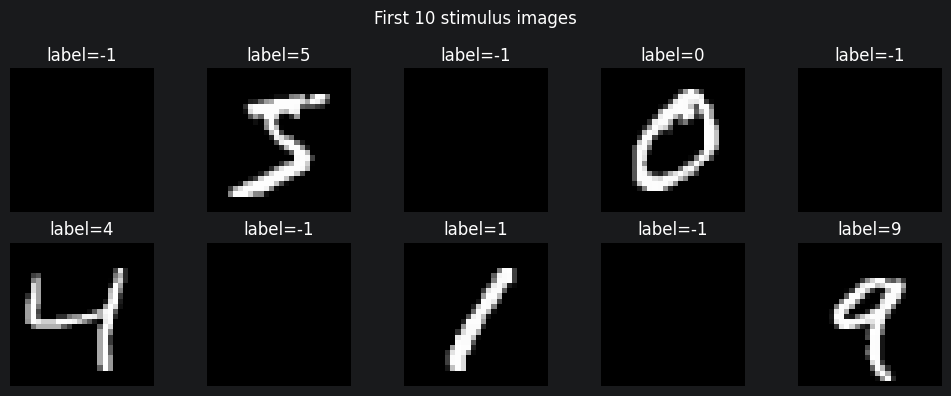

In [7]:
# --- visualize sample images ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"label={meta[i]['label']}")
    ax.axis("off")
plt.suptitle("First 10 stimulus images")
plt.tight_layout()
plt.show()

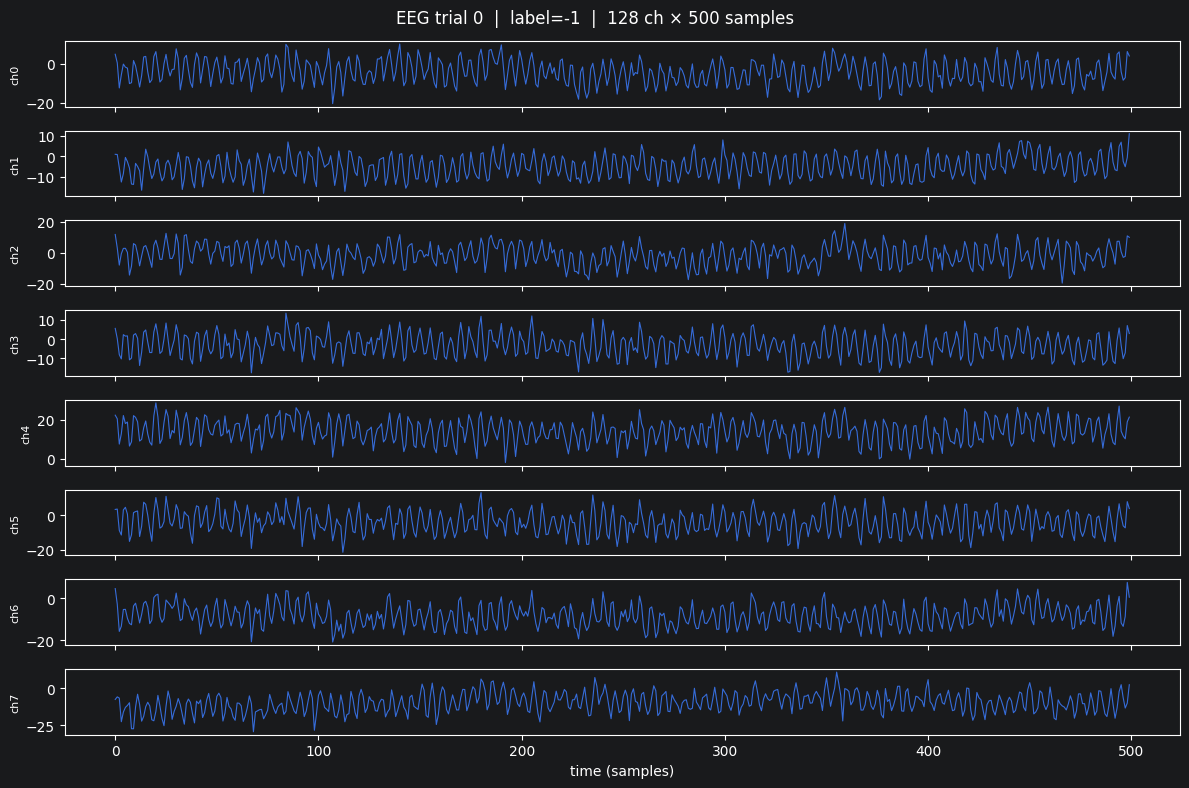

EEG value range: [-523.723, 518.656]  mean=0.118  std=14.489


In [8]:
# --- EEG quick look: first trial, first 8 channels ---
fig, axes = plt.subplots(8, 1, figsize=(12, 8), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(eeg[0, ch, :], linewidth=0.8)
    ax.set_ylabel(f"ch{ch}", fontsize=8)
axes[-1].set_xlabel("time (samples)")
plt.suptitle(f"EEG trial 0  |  label={meta[0]['label']}  |  128 ch × 500 samples")
plt.tight_layout()
plt.show()

print(f"EEG value range: [{eeg.min():.3f}, {eeg.max():.3f}]  mean={eeg.mean():.3f}  std={eeg.std():.3f}")

## MNE Filtering (1–40 Hz bandpass)

Convert ADC counts → Volts, wrap in `mne.EpochsArray`, apply zero-phase FIR filter.

In [10]:
import mne

SFREQ = 250.0  # Hz
L_FREQ = 1.0   # Hz
H_FREQ = 40.0  # Hz

n_epochs, n_chs, n_times = eeg.shape  # (1668, 128, 500)
ch_names = [f"EEG{i:03d}" for i in range(n_chs)]
info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")

# ADC counts → µV → V  (MNE internal unit is V)
eeg_v = (eeg / 1000.0) * 1e-6

epochs = mne.EpochsArray(eeg_v, info, verbose=False)
epochs.filter(l_freq=L_FREQ, h_freq=H_FREQ, method="fir", fir_window="hamming", verbose=False)

eeg_filtered = epochs.get_data()  # (1668, 128, 500)  in Volts
print(f"filtered shape : {eeg_filtered.shape}")
print(f"filtered range : [{eeg_filtered.min()*1e6:.3f}, {eeg_filtered.max()*1e6:.3f}] µV")

/tmp/ipykernel_195/3370750165.py:15: RuntimeWarning: filter_length (825) is longer than the signal (500), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=L_FREQ, h_freq=H_FREQ, method="fir", fir_window="hamming", verbose=False)


filtered shape : (1668, 128, 500)
filtered range : [-0.417, 0.295] µV


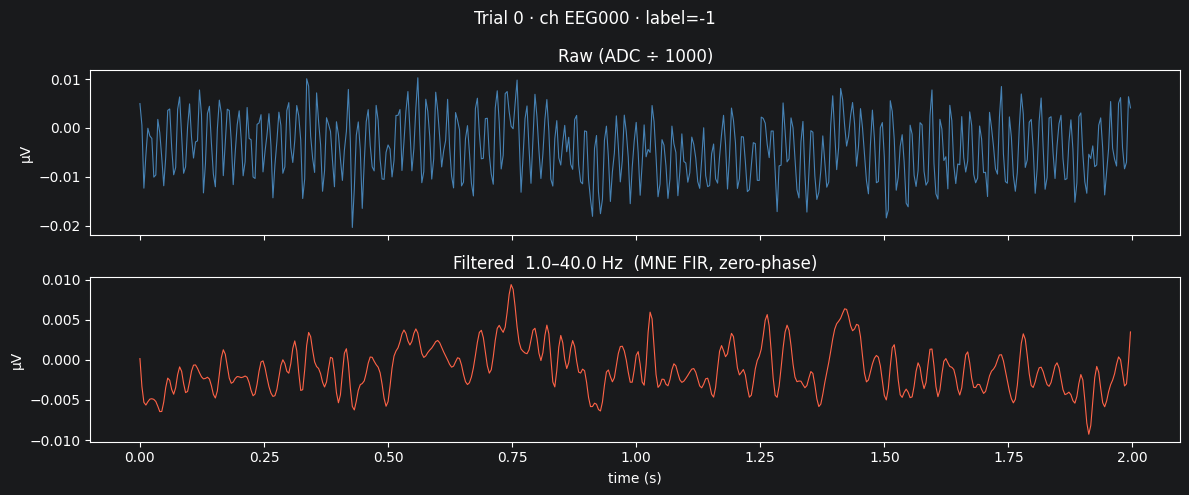

In [11]:
# --- before / after comparison for trial 0, channel 0 ---
times = np.arange(n_times) / SFREQ  # seconds

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(times, eeg[0, 0, :] / 1000.0, linewidth=0.8, color="steelblue")
axes[0].set_ylabel("µV")
axes[0].set_title("Raw (ADC ÷ 1000)")

axes[1].plot(times, eeg_filtered[0, 0, :] * 1e6, linewidth=0.8, color="tomato")
axes[1].set_ylabel("µV")
axes[1].set_title(f"Filtered  {L_FREQ}–{H_FREQ} Hz  (MNE FIR, zero-phase)")
axes[1].set_xlabel("time (s)")

plt.suptitle(f"Trial 0 · ch EEG000 · label={meta[0]['label']}")
plt.tight_layout()
plt.show()